In [ ]:
!pip install pygad
!pip install torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 110.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 95.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 43.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstallin


Summary Comparison Table:
        Method  Execution Time (s)  Total Cost / -Fitness
0       Greedy            0.002090           7.167173e+06
1  GA Parallel          129.253587           1.044191e+08
2    GA Serial           13.643024           1.046161e+08


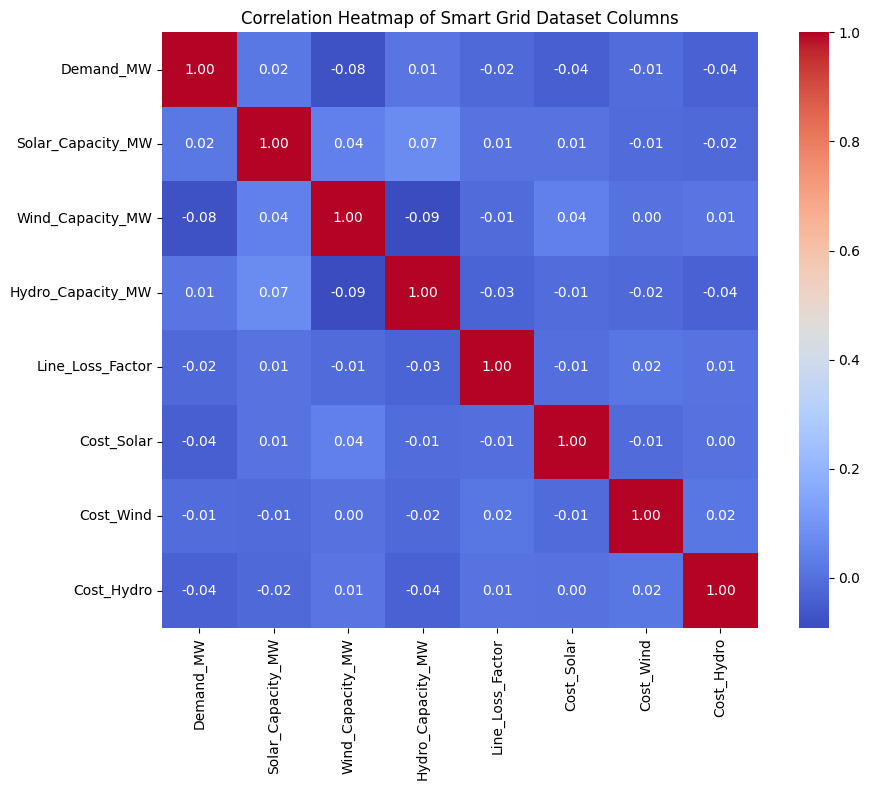

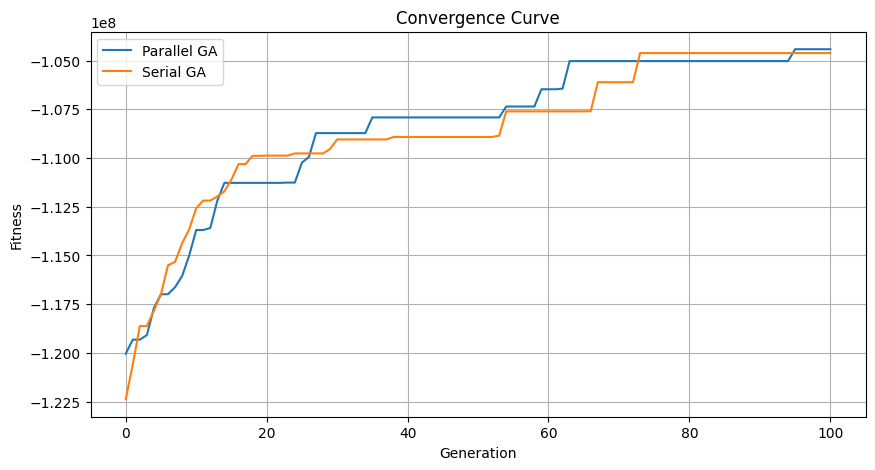

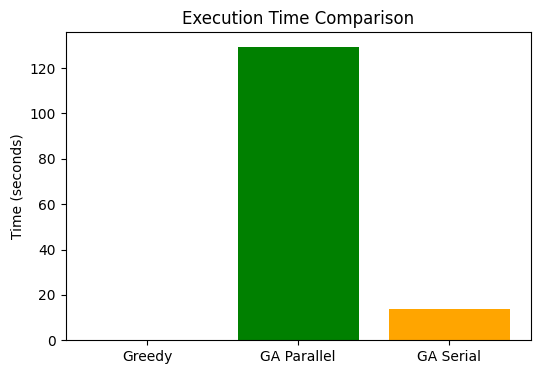

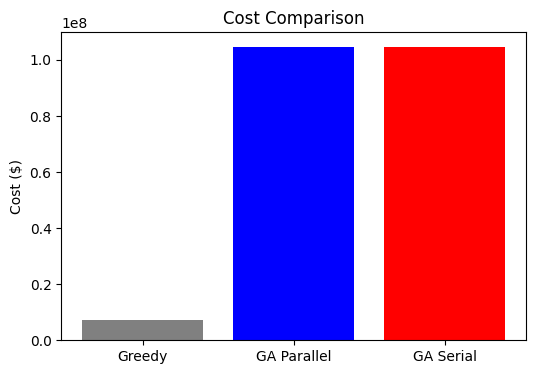

In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import pygad
import torch
import time
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Function to generate a realistic smart grid dataset
def generate_smart_grid_dataset(nodes=30, sources=3, hours=24):
    # Simulate hourly demand and renewable energy capacities for each node
    data = {
        'Hour': np.repeat(range(hours), nodes),
        'Node': np.tile(range(nodes), hours),
        'Demand_MW': np.random.uniform(50, 200, nodes * hours),
        'Solar_Capacity_MW': np.random.uniform(0, 100, nodes * hours),
        'Wind_Capacity_MW': np.random.uniform(0, 150, nodes * hours),
        'Hydro_Capacity_MW': np.random.uniform(0, 120, nodes * hours),
        'Line_Loss_Factor': np.random.uniform(0.05, 0.15, nodes * hours),
        'Cost_Solar': np.random.uniform(0.08, 0.12, nodes * hours),
        'Cost_Wind': np.random.uniform(0.06, 0.10, nodes * hours),
        'Cost_Hydro': np.random.uniform(0.04, 0.08, nodes * hours),
    }
    return pd.DataFrame(data)

# Generate dataset
dataset = generate_smart_grid_dataset()

# Class for smart grid optimization using Genetic Algorithm and Greedy approach
class SmartGridOptimizer:
    def __init__(self, dataset, nodes=30, sources=3, hours=24):
        self.dataset = dataset
        self.nodes = nodes
        self.sources = sources
        self.hours = hours

        # Reshape data into (hours x nodes) matrices for easier computation
        self.max_capacity = {
            'Solar': dataset['Solar_Capacity_MW'].values.reshape(hours, nodes),
            'Wind': dataset['Wind_Capacity_MW'].values.reshape(hours, nodes),
            'Hydro': dataset['Hydro_Capacity_MW'].values.reshape(hours, nodes)
        }
        self.demand = dataset['Demand_MW'].values.reshape(hours, nodes)
        self.line_loss = dataset['Line_Loss_Factor'].values.reshape(hours, nodes)
        self.costs = {
            'Solar': dataset['Cost_Solar'].values.reshape(hours, nodes),
            'Wind': dataset['Cost_Wind'].values.reshape(hours, nodes),
            'Hydro': dataset['Cost_Hydro'].values.reshape(hours, nodes)
        }

    # Fitness function for GA: calculates cost, penalties, and returns negative fitness
    def fitness_function(self, ga_instance, solution, solution_idx):
        solution = solution.reshape(self.hours, self.nodes, self.sources)
        solution_tensor = torch.tensor(solution, dtype=torch.float32)

        # Total cost from all sources
        cost = 0
        for s, source in enumerate(['Solar', 'Wind', 'Hydro']):
            cost += torch.sum(solution_tensor[:, :, s] * torch.tensor(self.costs[source], dtype=torch.float32) * 1000)

        # Penalty for line losses
        line_loss_tensor = torch.tensor(self.line_loss, dtype=torch.float32).unsqueeze(2).expand(-1, -1, self.sources)
        loss = torch.sum(solution_tensor * line_loss_tensor)

        # Penalty for unmet demand
        total_supply = torch.sum(solution_tensor, dim=2)
        demand_penalty = torch.sum(torch.abs(total_supply - torch.tensor(self.demand, dtype=torch.float32)))

        # Penalty for exceeding capacity
        penalty = 0
        for s, source in enumerate(['Solar', 'Wind', 'Hydro']):
            excess = torch.relu(solution_tensor[:, :, s] - torch.tensor(self.max_capacity[source], dtype=torch.float32))
            penalty += torch.sum(excess) * 1000

        # Return negative fitness since GA maximizes the objective
        fitness = -(cost + 0.5 * loss + 0.1 * demand_penalty + penalty)
        return fitness.item()

    # Define the allowed range for each gene in the chromosome
    def chromosome_encoding(self):
        return [{'low': 0, 'high': 200} for _ in range(self.hours * self.nodes * self.sources)]

    # Greedy algorithm: fulfill demand using cheapest source first
    def greedy_baseline(self):
        allocation = np.zeros((self.hours, self.nodes, self.sources))
        demand_remaining = self.demand.copy()
        source_order = ['Hydro', 'Wind', 'Solar']  # From cheapest to most expensive

        for s, source in enumerate(source_order):
            capacity = self.max_capacity[source]
            for h in range(self.hours):
                for n in range(self.nodes):
                    allocated = min(demand_remaining[h, n], capacity[h, n])
                    allocation[h, n, s] = allocated
                    demand_remaining[h, n] -= allocated

        total_cost = 0
        for s, source in enumerate(['Solar', 'Wind', 'Hydro']):
            total_cost += np.sum(allocation[:, :, s] * self.costs[source] * 1000)

        return total_cost, allocation

# Function to run the Genetic Algorithm
def run_ga(optimizer, parallel=True):
    ga_instance = pygad.GA(
        num_generations=100,
        num_parents_mating=20,
        fitness_func=optimizer.fitness_function,
        sol_per_pop=50,
        num_genes=optimizer.hours * optimizer.nodes * optimizer.sources,
        gene_space=optimizer.chromosome_encoding(),
        mutation_percent_genes=10,
        parallel_processing=['process', os.cpu_count()] if parallel else None
    )

    # Measure execution time
    start = time.time()
    ga_instance.run()
    end = time.time()

    # Get best solution and reshape to 3D
    best_solution = ga_instance.best_solution()[0].reshape(optimizer.hours, optimizer.nodes, optimizer.sources)
    best_fitness = ga_instance.best_solution()[1]

    return ga_instance, end - start, best_fitness, best_solution

# Main function to execute optimization, run comparisons, and visualize
def main():
    optimizer = SmartGridOptimizer(dataset)

    # Run Greedy baseline
    start_greedy = time.time()
    greedy_cost, greedy_sol = optimizer.greedy_baseline()
    end_greedy = time.time()
    greedy_time = end_greedy - start_greedy

    # Run Genetic Algorithm in parallel and serial modes
    parallel_ga, parallel_time, parallel_fitness, parallel_sol = run_ga(optimizer, parallel=True)
    serial_ga, serial_time, serial_fitness, serial_sol = run_ga(optimizer, parallel=False)

    # Display summary comparison table
    summary = pd.DataFrame({
        'Method': ['Greedy', 'GA Parallel', 'GA Serial'],
        'Execution Time (s)': [greedy_time, parallel_time, serial_time],
        'Total Cost / -Fitness': [greedy_cost, -parallel_fitness, -serial_fitness]
    })

    print("\nSummary Comparison Table:")
    print(summary)

    # Plot correlation heatmap of dataset variables (excluding categorical columns)
    numeric_data = dataset.drop(columns=['Hour', 'Node'])
    corr_matrix = numeric_data.corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
    plt.title("Correlation Heatmap of Smart Grid Dataset Columns")
    plt.tight_layout()
    plt.show()

    # Plot convergence curve of fitness over generations
    plt.figure(figsize=(10, 5))
    plt.plot(parallel_ga.best_solutions_fitness, label='Parallel GA')
    plt.plot(serial_ga.best_solutions_fitness, label='Serial GA')
    plt.xlabel("Generation")
    plt.ylabel("Fitness")
    plt.title("Convergence Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot execution time comparison
    plt.figure(figsize=(6, 4))
    plt.bar(['Greedy', 'GA Parallel', 'GA Serial'], [greedy_time, parallel_time, serial_time],
            color=['gray', 'green', 'orange'])
    plt.title("Execution Time Comparison")
    plt.ylabel("Time (seconds)")
    plt.show()

    # Plot total cost comparison
    plt.figure(figsize=(6, 4))
    plt.bar(['Greedy', 'GA Parallel', 'GA Serial'], [greedy_cost, -parallel_fitness, -serial_fitness],
            color=['gray', 'blue', 'red'])
    plt.title("Cost Comparison")
    plt.ylabel("Cost ($)")
    plt.show()

# Run the full simulation
if __name__ == "__main__":
    main()
